In [4]:
import os
import numpy as np
import pandas as pd
import librosa

In [10]:
music_df = pd.read_csv('C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\MIREX.csv')
music_df

,song_id,energy,loudness,tempo,key,mode,time_signature,cluster,category
0,1,0.022155,-15.036412,120.185320,8,1,1.010972,1,Boisterous
1,2,0.010367,-26.363678,156.605114,9,1,0.893642,1,Boisterous
2,3,0.022840,-17.429565,105.468750,9,1,0.974649,1,Boisterous
3,4,0.035078,-12.957283,93.963068,2,1,0.925274,1,Boisterous
4,5,0.015994,-18.270273,103.359375,6,1,0.964630,1,Boisterous
...,...,...,...,...,...,...,...,...,...
898,899,0.011995,-22.777634,147.656250,4,1,0.931142,5,Volatile
899,900,0.016072,-14.258656,143.554688,2,1,0.957746,5,Volatile
900,901,0.031603,-13.698313,97.508844,11,1,0.934561,5,Volatile
901,902,0.013646,-18.903427,97.508844,6,1,0.953834,5,Volatile


# data load

In [55]:
import zipfile

# 파일 경로
zip_file_path = 'C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\MIREX-like_mood.zip'

# 압축 해제
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  zip_ref.extractall('C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX')

print(f"{zip_file_path} 압축 해제 완료!")

C:\Users\swu\Desktop\Min\Project3\MIREX\MIREX-like_mood.zip 압축 해제 완료!


In [56]:
# 오디오 파일 디렉토리 경로
audio_dir = 'C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\dataset\\Audio'

# 주석 파일 로드
cluster_file_path = 'C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\dataset\\clusters.txt'
cluster_df = pd.read_csv(cluster_file_path, header=None, names=['cluster'])
category_file_path = 'C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\dataset\\categories.txt'
category_df = pd.read_csv(category_file_path, header=None, names=['category'])

In [57]:
mood_df = pd.concat([cluster_df['cluster'], category_df['category']], axis=1)
mood_df

,cluster,category
0,Cluster 1,Boisterous
1,Cluster 1,Boisterous
2,Cluster 1,Boisterous
3,Cluster 1,Boisterous
4,Cluster 1,Boisterous
...,...,...
898,Cluster 5,Volatile
899,Cluster 5,Volatile
900,Cluster 5,Volatile
901,Cluster 5,Volatile


# audio feaures extraction

## Spotify API ver.

In [ ]:
#!pip install pymusickit
from pymusickit.key_finder import KeyFinder
import librosa

def extract_audio_features(file_path):
    # 오디오 파일 로드
    y, sr = librosa.load(file_path, sr=None)

    # 에너지 계산
    energy = np.sum(y**2) / len(y)

    # 음량(Loudness) 계산
    S = np.abs(librosa.stft(y))
    loudness = np.mean(librosa.amplitude_to_db(S))

    # 템포(Tempo) 추정
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # 키(Key) 및 모드(Mode) 추정
    song = KeyFinder(file_path)
    key = song.key
    mode = song.mode  # 1: Major, 0: Minor

    # 박자(Time Signature) 추정
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    times = librosa.times_like(onset_env, sr=sr)
    tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    beat_times = librosa.frames_to_time(beats, sr=sr)
    time_signature = len(beat_times) / (times[-1] / 60) / tempo

    return {
        'energy': energy,
        'loudness': loudness,
        'tempo': tempo,
        'key': key,
        'mode': mode,
        'time_signature': time_signature
    }

In [ ]:
features = []

for idx, row in mood_df.iterrows():
    song_id = idx+1
    file_path = os.path.join(audio_dir, f'{song_id:03d}.mp3')

    if os.path.exists(file_path):
        audio_features = extract_audio_features(file_path)
        audio_features.update({
            'song_id': song_id,
            'cluster': row['cluster'],
            'category': row['category']
        })
        features.append(audio_features)
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')

# 데이터프레임 생성
mirex_df_re = pd.DataFrame(features)

AttributeError: 'KeyFinder' object has no attribute 'key'

In [ ]:
mirex_df

NameError: name 'mirex_df' is not defined

In [ ]:
mirex_df['tempo'] = mirex_df['tempo'].apply(lambda x: x[0] if len(x) == 1 else x)
mirex_df['time_signature'] = mirex_df['time_signature'].apply(lambda x: x[0] if len(x) == 1 else x)

In [ ]:
mirex_df.to_csv('MIREX.csv', index=False)

array([[<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'time_signature'}>],
       [<Axes: title={'center': 'song_id'}>,
        <Axes: title={'center': 'valence_mean'}>,
        <Axes: title={'center': 'arousal_mean'}>]], dtype=object)

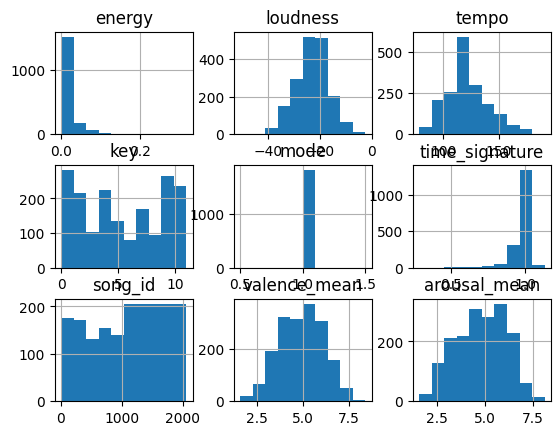

In [ ]:
mirex_df.hist()

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,139.674831,9,1,1.001031,2.0,3.10,3.00
1,0.017426,-25.533651,95.703125,4,1,0.988654,3.0,3.50,3.30
2,0.039658,-18.046253,112.347147,9,1,1.008252,4.0,5.70,5.50
3,0.024600,-20.400837,123.046875,11,1,1.018051,5.0,4.40,5.30
4,0.074468,-19.637709,120.185320,4,1,0.997166,7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,178.205819,11,1,0.972539,2054.0,5.40,3.60
1798,0.030940,-15.287614,123.046875,9,1,1.004990,2055.0,5.00,5.20
1799,0.008828,-25.813923,99.384014,4,1,0.973944,2056.0,5.00,4.60
1800,0.033607,-13.712579,126.048018,11,1,0.990992,2057.0,3.17,6.83


# Classification Model

# Melspectogram

In [80]:
x, sr = librosa.load(WavPath+Fils[2])
plt.figure(figsize=(14, 5))
S = librosa.feature.melspectrogram(x, sr=sample_rate, n_mels=128)
log_S = librosa.power_to_db(S, ref=np.max)
MFCC = librosa.feature.mfcc(S=log_S, n_mfcc=23)
delta2_mfcc = librosa.feature.delta(MFCC, order=2)

#MFCC = librosa.feature.mfcc(y=x, sr=sample_rate,n_mfcc=23,dct_type=2)
librosa.display.specshow(log_S)
#print(np.max(MFCC),np.min(MFCC))
#MFCC = (MFCC+200)/500
#print(np.max(MFCC),np.min(MFCC))
plt.colorbar()
plt.tight_layout()

NameError: name 'WavPath' is not defined

In [79]:
# 데이터셋 로드 및 분할
audio_path = 'C:\\Users\\swu\\Desktop\\Min\\Project3\\MIREX\\dataset\\Audio'
dataset = MIREXDataset(mood_df, audio_path)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [78]:
# 모델, 손실 함수, 옵티마이저 정의
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 훈련 루프
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for mel_spec, labels in train_loader:
        mel_spec, labels = mel_spec.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(mel_spec)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x331776 and 32768x128)

In [ ]:
# 모델 저장
torch.save(model.state_dict(), 'mirex_audio_cnn.pth')

## 신경망

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [12]:
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']].values
y = music_df[['cluster']].values

encoder = OneHotEncoder(categories='auto', sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train - val split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [13]:
class MultiClassificationModel(nn.Module):
    def __init__(self, input_dim, output_dim=5):
        super().__init__()

        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

def loss_fn(y_pred, y_true):
    ce = nn.CrossEntropyLoss()
    loss = ce(y_pred, y_true)
    return loss

In [14]:
input_dim = X_train_tensor.shape[1]
model = MultiClassificationModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 파라미터 설정
epochs = 30
train_loss = []
val_loss = []

# 훈련 루프
model.train()
for epoch in range(epochs):
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = 0
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, '
          f'Val Loss: {avg_val_loss:.4f}')

    train_loss.append(avg_train_loss)
    val_loss.append(avg_val_loss)

Epoch [1/30], Train Loss: 1.6887, Val Loss: 1.6169
Epoch [2/30], Train Loss: 1.5834, Val Loss: 1.6100
Epoch [3/30], Train Loss: 1.5690, Val Loss: 1.6054
Epoch [4/30], Train Loss: 1.5511, Val Loss: 1.6059
Epoch [5/30], Train Loss: 1.5361, Val Loss: 1.6091
Epoch [6/30], Train Loss: 1.5303, Val Loss: 1.6127
Epoch [7/30], Train Loss: 1.5177, Val Loss: 1.6142
Epoch [8/30], Train Loss: 1.5109, Val Loss: 1.6163
Epoch [9/30], Train Loss: 1.5009, Val Loss: 1.6198
Epoch [10/30], Train Loss: 1.4977, Val Loss: 1.6233
Epoch [11/30], Train Loss: 1.4951, Val Loss: 1.6274
Epoch [12/30], Train Loss: 1.4770, Val Loss: 1.6234
Epoch [13/30], Train Loss: 1.4677, Val Loss: 1.6264
Epoch [14/30], Train Loss: 1.4608, Val Loss: 1.6270
Epoch [15/30], Train Loss: 1.4537, Val Loss: 1.6293
Epoch [16/30], Train Loss: 1.4388, Val Loss: 1.6271
Epoch [17/30], Train Loss: 1.4382, Val Loss: 1.6355
Epoch [18/30], Train Loss: 1.4299, Val Loss: 1.6429
Epoch [19/30], Train Loss: 1.4144, Val Loss: 1.6460
Epoch [20/30], Train 

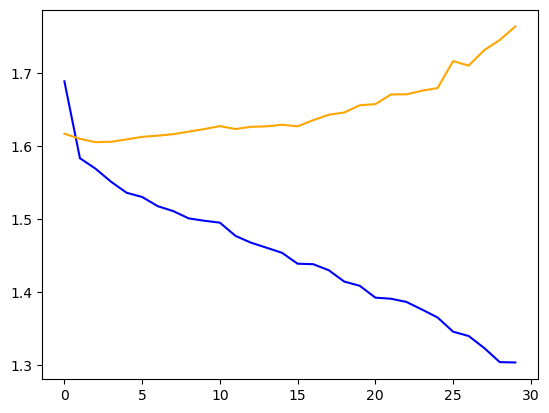

In [15]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

In [18]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_val_tensor)
    y_pred = torch.argmax(y_pred_tensor, dim=1).numpy()

# 평가 지표 계산
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = torch.argmax(y_val_tensor, dim=1).numpy()
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.2486
Precision: 0.2264
Recall: 0.2486
F1 Score: 0.2315


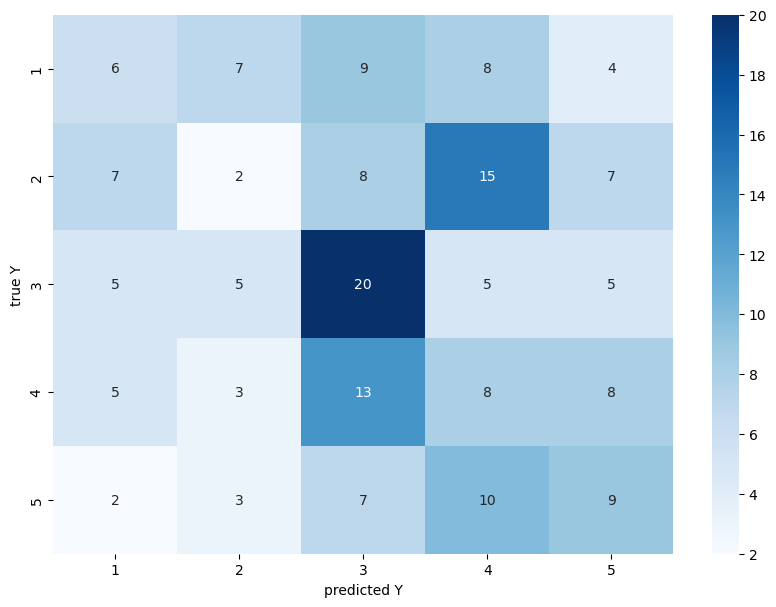

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 혼동 행렬 생성
cm = confusion_matrix(y_true, y_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.xlabel('predicted Y')
plt.ylabel('true Y')
plt.show()

In [41]:
music_df.cluster.value_counts(sort=False)

cluster
1    170
2    164
3    215
4    191
5    163
Name: count, dtype: int64

In [47]:
# 최빈값 계산
dummy_pred = torch.tensor([3]).expand(y_val_tensor.size(0), -1).cpu().numpy()

# 평가 지표 계산
dummy_accuracy = accuracy_score(y_true, dummy_pred)
dummy_precision = precision_score(y_true, dummy_pred, average='weighted')
dummy_recall = recall_score(y_true, dummy_pred, average='weighted')
dummy_f1 = f1_score(y_true, dummy_pred, average='weighted')

print(f'Accuracy: {dummy_accuracy:.4f}')
print(f'Precision: {dummy_precision:.4f}')
print(f'Recall: {dummy_recall:.4f}')
print(f'F1 Score: {dummy_f1:.4f}')

Accuracy: 0.2044
Precision: 0.0418
Recall: 0.2044
F1 Score: 0.0694


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
